In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
df = pd.read_csv("loan.csv")   # Change filename if needed

# Remove ID column
df.drop("Loan_ID", axis=1, inplace=True)

# Fill missing values
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in df.select_dtypes(include=["int64", "float64"]).columns:
    df[col] = df[col].fillna(df[col].median())

# Create target column (High Loan = 1, Low Loan = 0)
median_loan = df["LoanAmount"].median()
df["Loan_Class"] = np.where(df["LoanAmount"] >= median_loan, 1, 0)

# Drop original LoanAmount
X = df.drop("Loan_Class", axis=1)
X = X.drop("LoanAmount", axis=1)

y = df["Loan_Class"]

# Encode categorical columns
le = LabelEncoder()

for col in X.select_dtypes(include="object").columns:
    X[col] = le.fit_transform(X[col])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train Random Forest Classifier
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Results
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.5405405405405406

Classification Report

              precision    recall  f1-score   support

           0       0.47      0.65      0.54        31
           1       0.65      0.47      0.54        43

    accuracy                           0.54        74
   macro avg       0.56      0.56      0.54        74
weighted avg       0.57      0.54      0.54        74


Confusion Matrix

[[20 11]
 [23 20]]


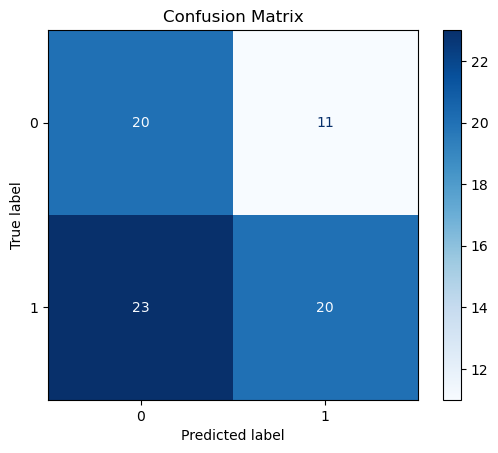

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [4]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Class
0,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban,0
1,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban,1
2,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban,1
3,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,1.0,Urban,0
4,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban,0
...,...,...,...,...,...,...,...,...,...,...,...,...
362,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban,0
363,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban,0
364,Male,No,0,Graduate,No,3250,1993,126.0,360.0,1.0,Semiurban,1
365,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural,1


<Axes: xlabel='Gender', ylabel='count'>

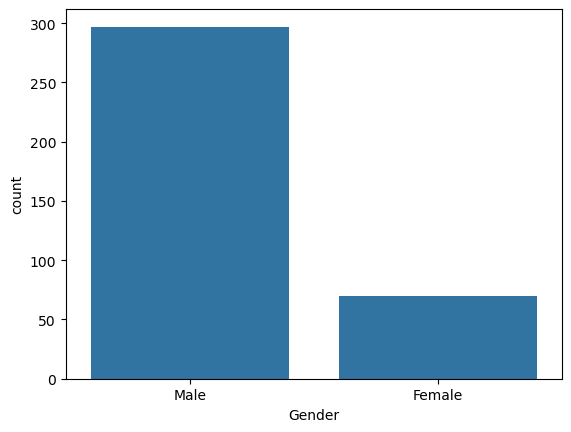

In [6]:
import seaborn as sns
sns.countplot(x = "Gender", data = df)

In [7]:
import pickle

# Save the trained Random Forest Classifier
with open("randomforestclassifier12.pkl", "wb") as file:
    pickle.dump(model, file)

print("Random Forest Classifier12 saved successfully!")

Random Forest Classifier12 saved successfully!


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("iris.csv")

# Display first 5 rows
print(df.head())

# -----------------------------
# Check Missing Values
# -----------------------------
print("\nMissing Values:")
print(df.isnull().sum())

# -----------------------------
# Encode Target Column
# -----------------------------
encoder = LabelEncoder()
df["species"] = encoder.fit_transform(df["species"])

# -----------------------------
# Features and Target
# -----------------------------
X = df.drop("species", axis=1)
y = df["species"]

# -----------------------------
# Train Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# Train SVC Model
# -----------------------------
model = SVC(
    kernel="linear",
    random_state=42
)

model.fit(X_train, y_train)

# -----------------------------
# Prediction
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
print("\nAccuracy :", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Accuracy : 1.0

Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [14]:
import pickle

# Save the trained Random Forest Classifier
with open("SVC.pkl", "wb") as file:
    pickle.dump(model, file)

print("SVC saved successfully!")

SVC saved successfully!
